# Testing DATA integration through Tango

This notebook checks the real-hardware DATA flow:

1. Connect to Tango devices.
2. Configure the DATA Tango device.
3. Acquire a STEM image from ThermoMicroscope.
4. Use the returned saved file path to retrieve data through the DATA device.


### Quick Start Code Cell

In [1]:
import os
import json
import time
from getpass import getpass

import tango
import numpy as np
import matplotlib.pyplot as plt


## 0. Ping Tango servers


In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
DB_HOST = "10.46.217.241"
# DB_HOST = "127.0.0.1"
DB_PORT = 9094
# DB_PORT = 9000
server_list = [("stage", "asyncroscopy.hardware.STAGE"),
               ("scan", "asyncroscopy.hardware.SCAN"),
               ("eds", "asyncroscopy.detectors.EDS"),
               ("camera", "asyncroscopy.detectors.CAMERA"),
               ("data", "asyncroscopy.software.DATA"),
               ("corrector", "asyncroscopy.hardware.CORRECTOR"),
               ("microscope", "asyncroscopy.ThermoMicroscope")]
# ─────────────────────────────────────────────────────────────────────────────

PROJECT_DIR = os.path.dirname(os.getcwd())
os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"
env = {**os.environ, "TANGO_HOST": f"{DB_HOST}:{DB_PORT}"}
processes = {}


def wait_for_device(name, timeout=2, interval=1):
    print(f"  Waiting for {name}...", end="", flush=True)
    start = time.time()
    while time.time() - start < timeout:
        try:
            tango.DeviceProxy(name).ping()
            print(f" ✅ ready ({time.time()-start:.1f}s)")
            return True
        except Exception:
            print(".", end="", flush=True)
            time.sleep(interval)
    print(f" ❌ timed out after {timeout}s")
    return False

def check_processes(*names):
    for name in names:
        p = processes[name]
        print(f"\n─── {name} (PID {p.pid}) ───\n  Running: {p.poll() is None}")
        for label, fd in [("STDOUT", p.stdout), ("STDERR", p.stderr)]:
            try:
                print(f"  {label}: {fd.read1(4096).decode() or '(empty)'}")
            except Exception:
                print(f"  {label}: (no output yet)")



if not all(wait_for_device(f"asyncroscopy/{d}/default") for d in ["stage", "scan", "eds", "camera", "data"]):
    print("\n⚠️  Debug info:")
    check_processes("stage", "scan", "eds", "camera", "data")
    raise RuntimeError("One or more device servers failed.")


print("\n✅ All servers ready!")



  Waiting for asyncroscopy/stage/default... ✅ ready (0.2s)
  Waiting for asyncroscopy/scan/default... ✅ ready (0.2s)
  Waiting for asyncroscopy/eds/default... ✅ ready (0.2s)
  Waiting for asyncroscopy/camera/default... ✅ ready (0.2s)
  Waiting for asyncroscopy/data/default... ✅ ready (0.2s)

✅ All servers ready!


## 1. Connect to devices

In [3]:
db = tango.Database()
print("Devices registered in Tango DB:\n")
for device in db.get_device_name("*", "*"):
    print(device)


Devices registered in Tango DB:

asyncroscopy/camera/default
asyncroscopy/corrector/default
asyncroscopy/data/default
asyncroscopy/eds/default
asyncroscopy/flucam/default
asyncroscopy/microscope/default
asyncroscopy/scan/default
asyncroscopy/stage/default
dserver/CAMERA/camera_instance
dserver/CORRECTOR/corrector_instance
dserver/DATA/data_instance
dserver/DataBaseds/2
dserver/EDS/eds_instance
dserver/FLUCAM/flucam_instance
dserver/SCAN/scan_instance
dserver/STAGE/stage_instance
dserver/TangoAccessControl/1
dserver/TangoTest/test
dserver/ThermoDigitalTwin/microscope_twin_instance
dserver/ThermoMicroscope/microscope_instance
sys/access_control/1
sys/database/2
sys/tg_test/1
test/camera/1
test/corrector/1
test/eds/1
test/microscope/1
test/microscope_twin/1
test/scan/1
test/stage/1


In [4]:
SCAN_DEVICE = "asyncroscopy/scan/default"
MICROSCOPE_DEVICE = "asyncroscopy/microscope/default"
DATA_DEVICE = "asyncroscopy/data/default"

In [5]:
scan = tango.DeviceProxy(SCAN_DEVICE)
microscope = tango.DeviceProxy(MICROSCOPE_DEVICE)


for proxy in (scan, microscope):
    proxy.set_timeout_millis(120_000)

print("scan      :", scan.state())
print("microscope:", microscope.state())


scan      : ON
microscope: ON


In [6]:
data = tango.DeviceProxy(DATA_DEVICE)
data.set_timeout_millis(120_000)

TILED_HOST = "10.46.217.241"
TILED_PORT = 9091

# TILED_HOST = "127.0.0.1"
# TILED_PORT = 9091

data.host = TILED_HOST
data.port = TILED_PORT
save_path = "D:/microscopedata/tiled/ahoust17/"
data.save_path = save_path

data.set_api_key(getpass("Enter your Tiled API key: "))
# print(json.dumps(json.loads(data.get_config()), indent=2))

'{"host": "10.46.217.241", "port": 9091, "uri": "http://10.46.217.241:9091", "save_path": "D:/microscopedata/tiled/ahoust17/", "root_path": "", "api_key_configured": true, "tiled_server": "no", "tiled_server_status": ""}'

In [7]:
# Start a real Tiled server if the configured DATA server is not already reachable.
if str(data.tiled_server).lower() != "yes":
    print("Tiled server is not responding; starting it from the DATA device...")
    config = json.loads(data.start_tiled_server())
else:
    print("Tiled server is already running.")
    config = json.loads(data.get_config())

print(json.dumps(config, indent=2))
if config.get("tiled_server") != "yes":
    raise RuntimeError("Tiled server did not start. Check DATA device logs and save_path permissions.")


Tiled server is not responding; starting it from the DATA device...
{
  "host": "10.46.217.241",
  "port": 9091,
  "uri": "http://10.46.217.241:9091",
  "save_path": "D:/microscopedata/tiled/ahoust17/",
  "root_path": "",
  "api_key_configured": true,
  "tiled_server": "yes",
  "tiled_server_status": "running; watcher started"
}


In [19]:
from tiled.client import from_uri
import matplotlib.pyplot as plt

client = from_uri("http://10.46.217.241:9091", api_key="secret")
list(client)

['stem_image_haadf_20260522T081859161980.tiff']

In [9]:
import json

recent = json.loads(data.get_recent())
[f["file_name"] for f in recent["files"]]

['.asyncroscopy_tiled_catalog.db',
 'stem_image_haadf_20260522T081859161980.tiff']

In [10]:
# See top-level entries only
file_names = list(client)
file_names

['stem_image_haadf_20260522T081859161980.tiff']

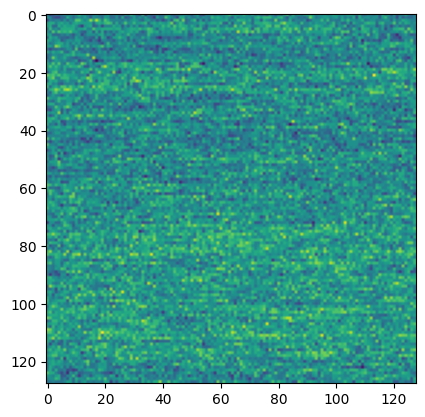

In [11]:
image = client[file_names[0]]


plt.figure()
plt.imshow(image)

## 3. Configure a small STEM acquisition

In [12]:
scan.Activate(["haadf"])
scan.dwell_time = 10e-6
scan.imsize = 128

print("dwell_time:", scan.dwell_time)
print("imsize    :", scan.imsize)


dwell_time: 1e-05
imsize    : 128


## 4. Acquire and inspect the saved path

Saved file: stem_image_haadf_20260522T083705771485.tiff


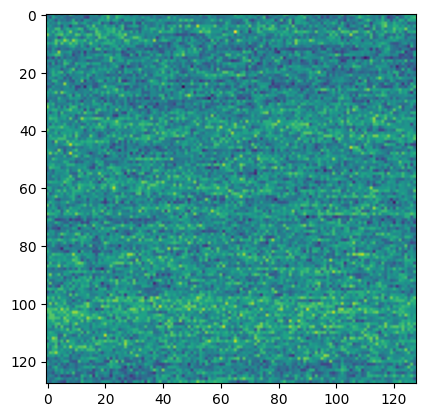

In [65]:
saved_path = microscope.get_scanned_image()

print("Saved file:", saved_path)

time.sleep(3)

image = client[saved_path].read()

plt.figure()
plt.imshow(image)

In [66]:
saved_path

'stem_image_haadf_20260522T083705771485.tiff'

In [67]:
list(client)

['stem_image_haadf_20260522T081859161980.tiff',
 'stem_image_haadf_20260522T082958377614.tiff',
 'stem_image_haadf_20260522T083226197741.tiff',
 'stem_image_haadf_20260522T083245210510.tiff',
 'stem_image_haadf_20260522T083257246460.tiff',
 'stem_image_haadf_20260522T083358186530.tiff',
 'stem_image_haadf_20260522T083447686419.tiff',
 'stem_image_haadf_20260522T083456763873.tiff',
 'stem_image_haadf_20260522T083512301432.tiff',
 'stem_image_haadf_20260522T083536710274.tiff',
 'stem_image_haadf_20260522T083541900589.tiff',
 'stem_image_haadf_20260522T083548557555.tiff',
 'stem_image_haadf_20260522T']

In [68]:
client['stem_image_haadf_20260522T083548557555.tiff']

<ArrayClient shape=(128, 128) chunks=((128,), (128,)) dtype=uint16>

In [58]:
metadata = client[saved_path].metadata

KeyError: 'stem_image_haadf_20260522T083548557555.tiff'

In [31]:
metadata

{'ImageWidth': 512,
 'ImageLength': 512,
 'BitsPerSample': 16,
 'Compression': <COMPRESSION.NONE: 1>,
 'PhotometricInterpretation': <PHOTOMETRIC.MINISBLACK: 1>,
 'StripOffsets': (15734,),
 'RowsPerStrip': 512,
 'StripByteCounts': (524288,),
 'PlanarConfiguration': <PLANARCONFIG.CONTIG: 1>,
 'ResolutionUnit': <RESUNIT.CENTIMETER: 3>,
 'FEI_TITAN': '<?xml version=\'1.0\' encoding=\'utf-8\'?>\n<Metadata xmlns:nil="http://schemas.fei.com/Metadata/v1/2013/07" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance">\n  <Core>\n    <Guid>453ea07f-5e21-4d95-86c2-a6a79a95c04b</Guid>\n    <ApplicationSoftware>AutoScript TEM</ApplicationSoftware>\n    <ApplicationSoftwareVersion>1.15.0.484</ApplicationSoftwareVersion>\n  </Core>\n  <Instrument>\n    <ControlSoftwareVersion>3.21.1</ControlSoftwareVersion>\n    <Manufacturer>FEI Company</Manufacturer>\n    <InstrumentClass>Titan</InstrumentClass>\n    <InstrumentModel>Spectra</InstrumentModel>\n    <InstrumentID>4018</InstrumentID>\n    <ComputerName

In [42]:
import tifffile
import pprint

image_path = save_path + saved_path + '.tiff'

with tifffile.TiffFile(image_path) as tif:
    page = tif.pages[0]

    print("="*80)
    print("ALL TIFF TAGS")
    print("="*80)

    for tag in page.tags.values():
        print(f"\n{tag.name}")
        print("-" * 50)
        
        try:
            if isinstance(tag.value, bytes):
                print(tag.value[:500])  # avoid gigantic dump
            else:
                pprint.pprint(tag.value)
        except Exception as e:
            print(f"<could not print> {e}")

    print("\n" + "="*80)
    print("TIFF SERIES")
    print("="*80)
    pprint.pprint(tif.series)

    print("\n" + "="*80)
    print("TIFF FLAGS")
    print("="*80)
    print("is_imagej:", tif.is_imagej)
    print("is_ome:", tif.is_ome)
    print("is_lsm:", tif.is_lsm)
    print("is_scn:", tif.is_scn)
    print("is_shaped:", tif.is_shaped)

ALL TIFF TAGS

ImageWidth
--------------------------------------------------
512

ImageLength
--------------------------------------------------
512

BitsPerSample
--------------------------------------------------
16

Compression
--------------------------------------------------
<COMPRESSION.NONE: 1>

PhotometricInterpretation
--------------------------------------------------
<PHOTOMETRIC.MINISBLACK: 1>

StripOffsets
--------------------------------------------------
(15734,)

RowsPerStrip
--------------------------------------------------
512

StripByteCounts
--------------------------------------------------
(524288,)

PlanarConfiguration
--------------------------------------------------
<PLANARCONFIG.CONTIG: 1>

ResolutionUnit
--------------------------------------------------
<RESUNIT.CENTIMETER: 3>

FEI_TITAN
--------------------------------------------------
("<?xml version='1.0' encoding='utf-8'?>\n"
 '<Metadata xmlns:nil="http://schemas.fei.com/Metadata/v1/2013/07" '
 'xmln

In [ ]:
def get_image():
    saved_path = microscope.get_scanned_image()
    image_path = save_path + saved_path + '.tiff'
    
    with tifffile.TiffFile(image_path) as tif:
        img, page = tif.asarray(), tif.pages[0]
        metadata = {tag.name: tag.value for tag in page.tags.values()}

    return img, metadata

## 5. Check recent files from the DATA device

In [11]:
print("Tiled root entries:")
try:
    print(json.dumps(json.loads(data.list_root()), indent=2)[:4000])
except Exception as exc:
    print("Could not list Tiled root:", exc)

recent = json.loads(data.get_recent())
print("\nRecent files visible to the DATA Tango device process:")
print(json.dumps(recent, indent=2)[:4000])


Tiled root entries:
{
  "path": "",
  "entries": []
}

Recent files visible to the DATA Tango device process:
{
  "save_path": "/Users/austin/Desktop/new_data/",
  "files": [
    {
      "path": "/Users/austin/Desktop/new_data/stem_image_haadf_20260520T172827_5894ecd7.tiff",
      "file_name": "stem_image_haadf_20260520T172827_5894ecd7.tiff",
      "relative_path": "stem_image_haadf_20260520T172827_5894ecd7.tiff",
      "size_bytes": 540022,
      "modified_time": 1779312508.0074947
    },
    {
      "path": "/Users/austin/Desktop/new_data/.asyncroscopy_tiled_catalog.db",
      "file_name": ".asyncroscopy_tiled_catalog.db",
      "relative_path": ".asyncroscopy_tiled_catalog.db",
      "size_bytes": 122880,
      "modified_time": 1779307855.9912214
    }
  ]
}


## 6. Resolve the saved path through Tiled

In [12]:
def get_data_with_retry(saved_path, timeout=30, interval=2):
    start = time.time()
    last_error = None
    while time.time() - start < timeout:
        try:
            return json.loads(data.get_data(saved_path))
        except Exception as exc:
            last_error = exc
            print("Tiled lookup not ready yet:", exc)
            time.sleep(interval)

    raise RuntimeError(f"Could not resolve data through Tiled after {timeout}s") from last_error

data = get_data_with_retry(saved_path)

if isinstance(data, dict):
    summary = {k: data[k] for k in data.keys() if k != "data"}
    print(json.dumps(summary, indent=2)[:4000])
else:
    print(type(data), str(data)[:1000])


Tiled lookup not ready yet: DevFailed[
    DevError[
        desc = KeyError: "Could not resolve path in Tiled. Tried: stem_image_haadf_20260520T172827_5894ecd7: 'stem_image_haadf_20260520T172827_5894ecd7'"
        origin = Traceback (most recent call last):
              File "/Users/austin/Documents/GitHub/asyncroscopy/.venv/lib/python3.12/site-packages/tango/server.py", line 1790, in wrapped_command_method
                return get_worker().execute(cmd_method, *args, **kwargs)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
              File "/Users/austin/Documents/GitHub/asyncroscopy/.venv/lib/python3.12/site-packages/tango/green.py", line 110, in execute
                return fn(*args, **kwargs)
                       ^^^^^^^^^^^^^^^^^^^
              File "/Users/austin/Documents/GitHub/asyncroscopy/asyncroscopy/software/DATA.py", line 211, in get_data
                return json.dumps(self._json_ready(self._read_node(self._node_for_path_or_saved_path

KeyboardInterrupt: 

## 7. Plot if Tiled returned an array

In [ ]:
if isinstance(data, dict) and data.get("type") == "ndarray":
    image = np.asarray(data["data"], dtype=np.dtype(data["dtype"]))
    image = image.reshape(data["shape"])

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image, cmap="gray", interpolation="none")
    ax.set_title("HAADF from Tiled")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Tiled did not return a direct ndarray. Inspect data and traverse the returned node/path as needed.")
